In [87]:
import json
import configparser

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from pathlib import Path
from itertools import product
from scipy.special import i1e, loggamma
from matplotlib.ticker import NullLocator
from mpl_toolkits.axes_grid1 import ImageGrid

mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['axes.unicode_minus'] = False

%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}

In [90]:
m_0 = 1.0
M_0 = 1e30
N_0 = M_0 / m_0
lambda_0 = 1.0 / M_0

def rect_inches(fig, left, bottom, width, height):
    fw, fh = fig.get_size_inches()
    return [left/fw, bottom/fh, width/fw, height/fh]

def const_w1_logmass(data, tau, m0):

    m = data["par_size"]**3
    w = data["par_numr"]*m
    w /= w.sum()

    x = np.linspace(-0.5, 9.5, 4097)
    idx = np.searchsorted(x, np.log10(m/m0), side = "right")
    F_sim = np.cumsum(np.bincount(idx, weights = w, minlength = len(x) + 1))[:-1]

    g = 1.0 / (1.0 + tau / 2.0)
    k = np.ceil(10.0**x).astype(np.int64) - 1
    F_ana = np.zeros_like(x)
    valid = k >= 1
    F_ana[valid] = -np.expm1(k[valid]*np.log1p(-g) + np.log1p(k[valid]*g))

    difference = np.abs(F_sim - F_ana)
    return np.sum(0.5*(difference[:-1] + difference[1:])*np.diff(x))

def model_w1(model):

    path_model = '/Users/jiaqingbi/Scratch/gamedev/test_const/{}/'.format(model)

    config = configparser.ConfigParser()
    config.read(path_model + 'variables.txt')

    frame = int(config["PARAMETERS"]["SAVE_MAX"])
    tau = float(config["PARAMETERS"]["DT_OUT"])*int(config["PARAMETERS"]["LOG_BASE"])**frame

    dtype = np.dtype([(name, dtype) for name, dtype in config['SWARM_DTYPE'].items()])
    data = np.fromfile(path_model + f'particle_{frame:05d}.dat', dtype = dtype)
    
    return const_w1_logmass(data, tau, m_0)

def get_mass (size): return size*size*size

def const_kernel (m, N_0, M_0, m_0, Lambda, t):
    h = 0.5*M_0*Lambda*t
    g = 1.0/(1.0+h)
    f = N_0*g*g*(1.0-g)**(m/m_0-1.0)
    return f*m*m / M_0 / m_0

def init_dist (m, N_0, M_0, m_0):
    f = N_0*np.exp(-m/m_0)/m_0
    return f*m*m / M_0 / m_0

def linear_kernel (m, N_0, M_0, m_0, Lambda, t):
    tau = M_0*Lambda*t
    g = np.exp(-tau)
    # Use exponentially scaled Bessel: i1e(x) = i1(x)*exp(-|x|)
    # This avoids overflow: i1(x)*exp(y) = i1e(x)*exp(x+y)
    arg = 2.0*m/m_0*np.sqrt(1.0-g)
    exponent = arg - m/m_0*(2.0-g)  # Combine exponentials
    f = N_0/m*(g/np.sqrt(1.0-g))*i1e(arg)*np.exp(exponent)
    return f*m*m / M_0 / m_0

def product_kernel (m, N_0, M_0, m_0, Lambda, t):
    eta = N_0*Lambda*t
    k = m / m_0
    # Work in log-space to avoid overflow
    # log(f) = log(N_0) + (k-1)*log(2*k) - log(k) - loggamma(k+1) + (k-1)*log(0.5*eta) - k*eta
    log_f = np.log(N_0) + (k-1.0)*np.log(2.0*k) - np.log(k) - loggamma(k+1.0) + (k-1.0)*np.log(0.5*eta) - k*eta
    # f*m*m = exp(log_f + 2*log(m))
    return np.exp(log_f + 2.0*np.log(m)) / M_0 / m_0

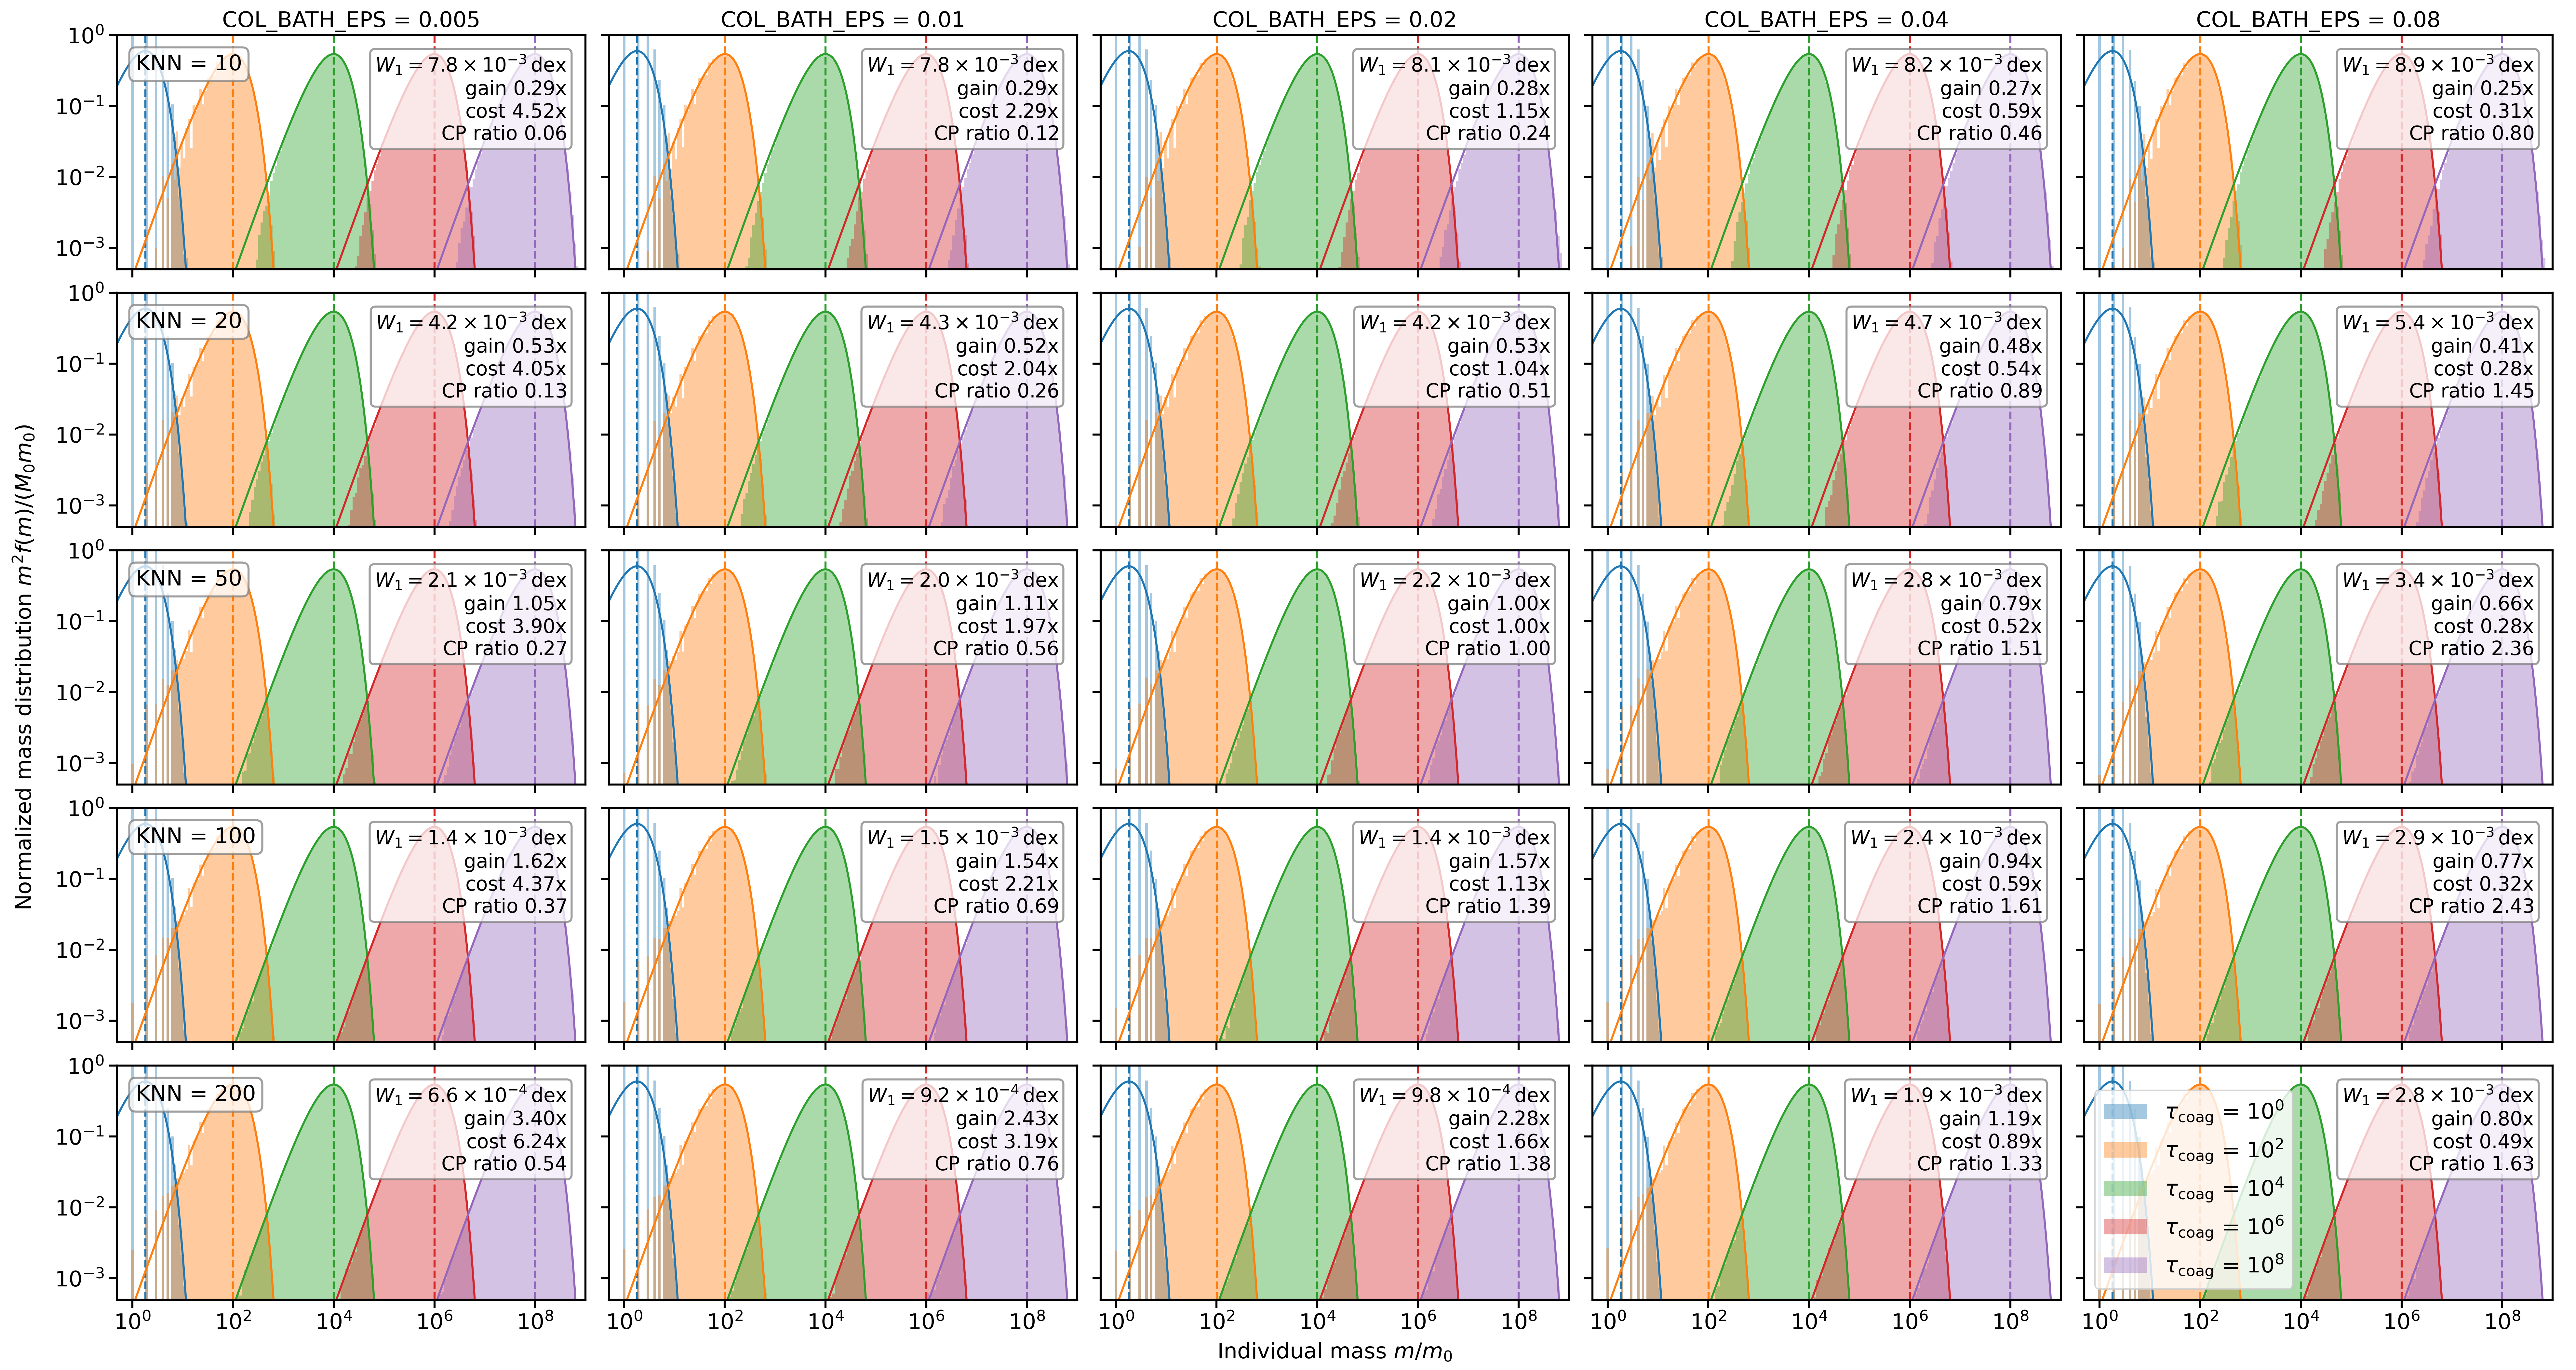

In [98]:
# const kernel

k_values   = ['1e+1', '2e+1', '5e+1', '1e+2', '2e+2']
b_values   = ['5e-3', '1e-2', '2e-2', '4e-2', '8e-2']
model_list = ['1e+6n_{}k_{}b'.format(k, b) for k, b in product(k_values, b_values)]

with Path('/Users/jiaqingbi/Scratch/gamedev/test_const/wall_time_summary.json').open() as file:
    timing = json.load(file)

wall_time = {
    entry['model']: entry['wall_seconds']
    for entry in timing['models']
}

model_ref = '1e+6n_5e+1k_2e-2b'
err_level = {model: model_w1(model) for model in model_list}
err_level_ref = err_level[model_ref]
wall_time_ref = wall_time[model_ref]

n_rows, n_cols = len(k_values), len(b_values)
margin_l, margin_r = 1.20, 0.24
margin_b, margin_t = 0.72, 0.36
panel_w, panel_h = 4.8, 2.4
gap_x, gap_y = 0.24, 0.24
axs_w = n_cols*panel_w + (n_cols - 1)*gap_x
axs_h = n_rows*panel_h + (n_rows - 1)*gap_y
fig_w = margin_l + axs_w + margin_r
fig_h = margin_t + axs_h + margin_b

fontsize = 16
linewidth = 1.5

fig = plt.figure(figsize = (fig_w, fig_h))
axs = ImageGrid(fig, nrows_ncols = (n_rows, n_cols), 
    rect = rect_inches(fig, margin_l, margin_b, axs_w, axs_h), 
    share_all = True, aspect = False, axes_pad = (gap_x, gap_y)
)

for idx_mod, model in enumerate(model_list):

    path_model = '/Users/jiaqingbi/Scratch/gamedev/test_const/{}/'.format(model)

    config = configparser.ConfigParser()
    config.read(path_model + 'variables.txt')

    dtype = np.dtype([(name, dtype) for name, dtype in config['SWARM_DTYPE'].items()])

    N_par = int(config['PARAMETERS']['N_P'])
    N_knn = int(config['PARAMETERS']['N_K'])
    eps = float(config['PARAMETERS']['COL_BATH_EPS'])

    x_min, x_max = 5e-1, 1e9
    y_min, y_max = 5e-4, 1e0
    x_bins = np.logspace(np.log10(x_min), np.log10(x_max), 200)
    xticks = [1e0, 1e2, 1e4, 1e6, 1e8]
    xtick_labels = ['$10^{:d}$'.format(int(np.log10(x))) for x in xticks]

    idx_file = [1,3,5,7,9]
    for i, snapshot in enumerate(idx_file):

        time = 10**(snapshot - 1)
        data = np.fromfile(path_model + f'particle_{snapshot:05d}.dat', dtype = dtype)

        s, n = data['par_size'], data['par_numr']
        m = get_mass(s)
        mu = m / m_0

        g = 1.0 / (1.0 + 0.5*time)
        mu_peak = -2.0 / np.log1p(-g)
        axs[idx_mod].axvline(x = mu_peak, ls = '--', color = f'C{i}', lw = linewidth)
        axs[idx_mod].plot(x_bins, const_kernel(x_bins, N_0, M_0, m_0, lambda_0, time), color = f'C{i}', lw = linewidth)

        hist = np.histogram(mu, weights = n*m / M_0, bins = x_bins)
        axs[idx_mod].stairs(
            hist[0] / np.diff(np.log(x_bins)), hist[1], fill = 1, alpha = 0.4,
            color = f'C{i}', label = f'$\\tau_\\mathrm{{coag}}$ = $10^{snapshot - 1:d}$'
        )

        # hist = np.histogram(mu, weights = n*mu*mu / N_0, bins = x_bins)
        # axs[idx_mod].stairs(
        #     hist[0] / np.diff(x_bins), hist[1], fill = 1, alpha = 0.4, 
        #     color = f'C{i}', label = f'$\\tau_\\mathrm{{coag}}$ = $10^{snapshot - 1:d}$'
        # )

    axs[idx_mod].set_xscale('log')
    axs[idx_mod].set_yscale('log')
    axs[idx_mod].set_xlim(x_min, x_max)
    axs[idx_mod].set_ylim(y_min, y_max)
    axs[idx_mod].set_xticks(xticks)
    axs[idx_mod].set_xticklabels(xtick_labels)
    axs[idx_mod].tick_params(axis = 'both', which = 'major', width = linewidth, length = 6, labelsize = fontsize)
    axs[idx_mod].yaxis.set_minor_locator(NullLocator())
    for spine in axs[idx_mod].spines.values(): spine.set_linewidth(linewidth)

    cost_factor = wall_time[model] / wall_time_ref
    gain_factor = err_level_ref / err_level[model]
    base, expo = f'{err_level[model]:.1e}'.split('e')
    cp_label  = rf'$W_1 = {float(base):.1f}\times10^{{{int(expo)}}}\,\mathrm{{dex}}$' + '\n' 
    cp_label += rf'gain ${gain_factor:.2f}$x' + '\n'
    cp_label += rf'cost ${cost_factor:.2f}$x' + '\n'
    cp_label += rf'CP ratio ${gain_factor/cost_factor:.2f}$'

    axs[idx_mod].text(0.96, 0.92, cp_label,
        transform = axs[idx_mod].transAxes, fontsize = 0.9*fontsize, va = 'top', ha = 'right',
        bbox = dict(boxstyle = 'round, pad = 0.25', facecolor = 'w', edgecolor = 'grey', linewidth = linewidth, alpha = 0.75),
    )

    if idx_mod == n_cols*n_rows - 1:
        axs[idx_mod].legend(loc = 'lower left', fontsize = fontsize)

    if idx_mod % n_cols == 0: 
        axs[idx_mod].text(0.04, 0.92, 'KNN = {:d}'.format(N_knn), 
            bbox = dict(boxstyle = 'round, pad = 0.3', facecolor = 'w', edgecolor = 'grey', linewidth = linewidth, alpha = 0.75),
            transform = axs[idx_mod].transAxes, fontsize = fontsize, va = 'top', ha = 'left'
        )

    if idx_mod // n_cols == 0:
        axs[idx_mod].set_title('COL_BATH_EPS = {}'.format(eps), fontsize = fontsize)

fig.supxlabel('Individual mass $m/m_0$',                         fontsize = fontsize, y = 0.1*margin_b / fig_h, x = (margin_l + 0.5*axs_w) / fig_w)
fig.supylabel('Normalized mass distribution $m^2f(m)/(M_0m_0)$', fontsize = fontsize, x = 0.1*margin_l / fig_w, y = (margin_b + 0.5*axs_h) / fig_h)

fig.show()